# 第二周作业：  MLP模型练习(fashion_mnist分类操作)

In [1]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
class_cnames = ['T恤','裤子','套头衫','连衣裙','外套','凉鞋','衬衫','运动鞋','包','短靴']

## 导包与GPU 配置

In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt
import os

# 检查并配置 GPU（如可用）
print('TensorFlow version:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPUs detected:', gpus)
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print('Enabled memory growth for GPUs')
    except Exception as e:
        print('Error setting memory growth:', e)



TensorFlow version: 2.10.1
GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Enabled memory growth for GPUs


## 数据加载与预处理

In [3]:
# 载入数据
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
print('raw shapes:', x_train.shape, y_train.shape, x_test.shape, y_test.shape)

# 展平并归一化
x_train = x_train.reshape(-1, 28*28).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28*28).astype('float32') / 255.0

# 标签独热编码
y_train_onehot = to_categorical(y_train, num_classes=10)
y_test_onehot = to_categorical(y_test, num_classes=10)

print('processed shapes:', x_train.shape, y_train_onehot.shape, x_test.shape, y_test_onehot.shape)

# 保存若干变量到全局供后续单元使用
print('Data ready')

raw shapes: (60000, 28, 28) (60000,) (10000, 28, 28) (10000,)
processed shapes: (60000, 784) (60000, 10) (10000, 784) (10000, 10)
Data ready


## 建立模型

In [4]:
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Dropout

# model = Sequential()
# model.add(Dense(units=256, input_dim=28*28, kernel_initializer='normal', activation='relu'))
# model.add(Dense(units=10, kernel_initializer='normal', activation='softmax'))

In [5]:
from tensorflow.keras import models, layers

model = models.Sequential([
    layers.Input(shape=(28*28,)),
    layers.Dense(128, activation='relu', kernel_initializer='he_normal'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu', kernel_initializer='he_normal'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

In [6]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               100480    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 10)                650       
                                                                 
Total params: 109,386
Trainable params: 109,386
Non-trainable params: 0
_________________________________________________________________


In [7]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

## 训练模型

In [8]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

train_history = model.fit(
    x=x_train, y = y_train_onehot, 
    validation_split=0.2, 
    epochs=20, 
    batch_size=128, 
    callbacks=[early_stop],
    verbose=2
)

Epoch 1/20
375/375 - 3s - loss: 0.7757 - accuracy: 0.7258 - val_loss: 0.4647 - val_accuracy: 0.8324 - 3s/epoch - 7ms/step
Epoch 2/20
375/375 - 1s - loss: 0.5091 - accuracy: 0.8201 - val_loss: 0.4044 - val_accuracy: 0.8557 - 679ms/epoch - 2ms/step
Epoch 3/20
375/375 - 1s - loss: 0.4552 - accuracy: 0.8387 - val_loss: 0.3878 - val_accuracy: 0.8582 - 666ms/epoch - 2ms/step
Epoch 4/20
375/375 - 1s - loss: 0.4254 - accuracy: 0.8480 - val_loss: 0.3663 - val_accuracy: 0.8659 - 663ms/epoch - 2ms/step
Epoch 5/20
375/375 - 1s - loss: 0.4064 - accuracy: 0.8545 - val_loss: 0.3606 - val_accuracy: 0.8692 - 668ms/epoch - 2ms/step
Epoch 6/20
375/375 - 1s - loss: 0.3906 - accuracy: 0.8590 - val_loss: 0.3503 - val_accuracy: 0.8731 - 658ms/epoch - 2ms/step
Epoch 7/20
375/375 - 1s - loss: 0.3773 - accuracy: 0.8642 - val_loss: 0.3585 - val_accuracy: 0.8739 - 756ms/epoch - 2ms/step
Epoch 8/20
375/375 - 1s - loss: 0.3641 - accuracy: 0.8682 - val_loss: 0.3490 - val_accuracy: 0.8759 - 755ms/epoch - 2ms/step
Epo

In [9]:
import matplotlib.pyplot as plt
def show_train_history(train_history, train, validation):
    plt.plot(train_history.history[train])
    plt.plot(train_history.history[validation])
    plt.title('Train History')
    plt.ylabel(train)
    plt.xlabel('Epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()

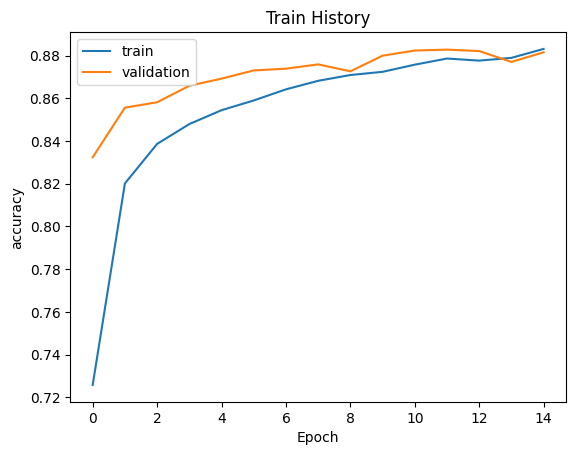

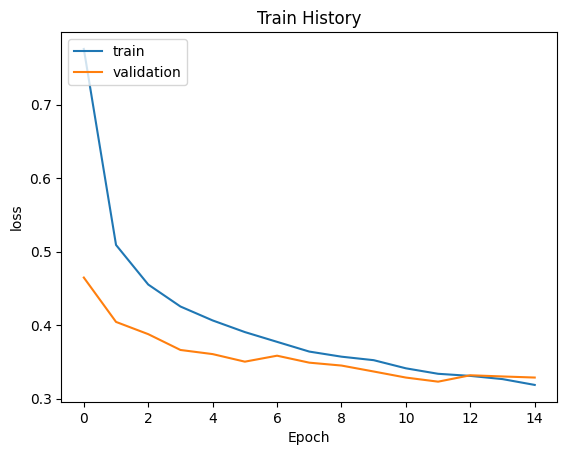

In [10]:
show_train_history(train_history, 'accuracy', 'val_accuracy')   # 准确率曲线
show_train_history(train_history, 'loss', 'val_loss')   # 损失曲线

In [11]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


## 评估模型的准确率

In [12]:
scores = model.evaluate(x_test, y_test_onehot)
print()
print('accuracy=', scores[1])
print(scores)

313/313 [==============================] - 1s 2ms/step - loss: 0.3458 - accuracy: 0.8750

accuracy= 0.875
[0.34582433104515076, 0.875]


## 进行预测

In [13]:
prediction = model.predict(x_test)
prediction_classes = prediction.argmax(axis=1)

313/313 [==============================] - 0s 944us/step


In [14]:
prediction_classes

array([9, 2, 1, ..., 8, 1, 5], dtype=int64)

In [15]:
import matplotlib.pyplot as plt
def plot_images_labels_prediction(images, label, prediction, index, num=10):
    fig = plt.gcf()
    fig.set_size_inches(12, 14)
    if num > 25: num = 25
    for i in range(0, num):
        ax = plt.subplot(5, 5, i+1)
        ax.imshow(images[index], cmap='binary')
        title = 'L=' + str(class_names[label[index]])
        if len(prediction) > 0:
            title += ',P=' + str(class_names[prediction[index]])
        ax.set_title(title, fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
        index += 1
    plt.show()  

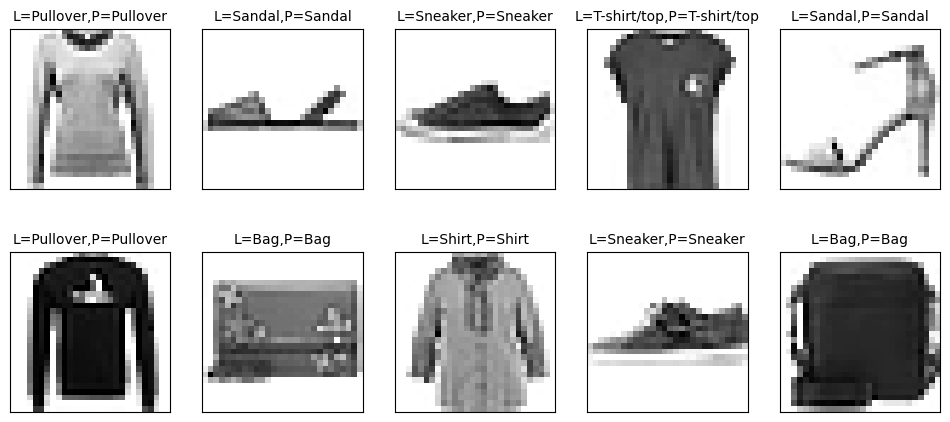

In [16]:
plot_images_labels_prediction(x_test.reshape(-1,28,28), y_test, prediction_classes, index=110)

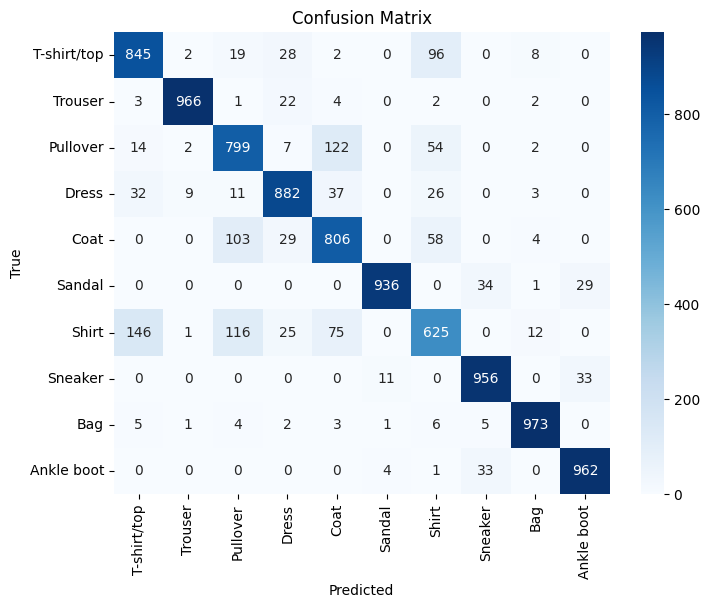

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, prediction_classes)      

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,                          # 混淆矩阵
    annot=True,                  # 在每个格子上显示数字
    fmt='d',                     # 整数格式（'d' 表示整数）
    cmap='Blues',                # 颜色风格（'Blues' 蓝白渐变，很经典）
    xticklabels=class_names,     # x轴标签（预测类别）
    yticklabels=class_names      # y轴标签（真实类别）
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()